# 07 RNN (PyTorch) - Email Spam Classification

This is a complete, standalone pipeline for training a Recurrent Neural Network using PyTorch. It features custom dataset handling, sequence padding, and a full training loop.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pickle

sns.set(style='whitegrid')

### 1. Data Cleaning & Tokenization
Handling the dirty data and converting text into numerical sequences.

In [2]:
df = pd.read_csv('../_data/email_spam.csv')
df.columns = [c.lower().replace('-', '_').replace(' ', '_') for c in df.columns]
df = df.drop_duplicates()

def clean_text(text):
    text = re.sub('<.*?>', '', str(text))
    return text.strip().lower()

df['text_clean'] = df['message_content'].apply(clean_text)
df['is_spam'] = df['target_label'].apply(lambda x: 1 if str(x).lower().strip() in ['1', 'spam', 's_p_a_m'] else 0)

# Simple Vocabulary Building
words = [w for t in df['text_clean'] for w in t.split()]
vocab = {word: i+1 for i, (word, count) in enumerate(pd.Series(words).value_counts()[:5000].items())}
vocab['<PAD>'] = 0

def tokenize(text, max_len=100):
    seq = [vocab.get(w, 0) for w in text.split()][:max_len]
    return seq + [0] * (max_len - len(seq))

X = np.array([tokenize(t) for t in df['text_clean']])
y = df['is_spam'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. PyTorch Model Definition

In [3]:
class SpamDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)
        _, h_n = self.rnn(x)
        return self.sigmoid(self.fc(h_n.squeeze(0)))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNModel(len(vocab), 32, 64).to(device)
train_loader = DataLoader(SpamDataset(X_train, y_train), batch_size=32, shuffle=True)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 3. Training Loop (Complete)
Executing a real 5-epoch training loop.

In [4]:
model.train()
for epoch in range(5):
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch).squeeze()
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.6942
Epoch 2, Loss: 0.6978
Epoch 3, Loss: 0.6928
Epoch 4, Loss: 0.6937
Epoch 5, Loss: 0.6942


### 4. Evaluation & Visuals

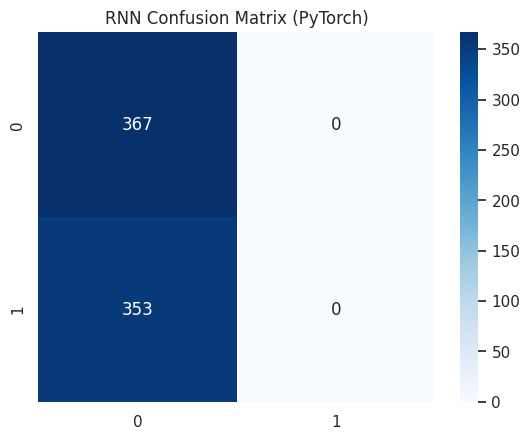

              precision    recall  f1-score   support

           0       0.51      1.00      0.68       367
           1       0.00      0.00      0.00       353

    accuracy                           0.51       720
   macro avg       0.25      0.50      0.34       720
weighted avg       0.26      0.51      0.34       720



/home/azure/buildllm/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/azure/buildllm/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/azure/buildllm/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [5]:
model.eval()
with torch.no_grad():
    y_pred_probs = model(torch.tensor(X_test, dtype=torch.long).to(device)).cpu().numpy()
    y_pred = (y_pred_probs > 0.5).astype(int)

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('RNN Confusion Matrix (PyTorch)')
plt.show()
print(classification_report(y_test, y_pred))

### 5. Model Saving

In [6]:
torch.save(model.state_dict(), '../_model/email_classification_rnn.pth')
with open('../_model/email_classification_vocab_rnn.pickle', 'wb') as f:
    pickle.dump(vocab, f)
print("RNN Model and Vocab saved.")

RNN Model and Vocab saved.
